##Часть 1 — Анализ FastQC


1)  В базе SRA Explorer найдем и скачаем данные секвенирования из проекта PRJEB84057:

>#!/usr/bin/env bash

>curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/095/ERR14230595/ERR14230595.fastq.gz -o ERR14230595_Illumina_HiSeq_4000_sequencing.fastq.gz
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/007/ERR14230607/ERR14230607.fastq.gz -o ERR14230607_Illumina_HiSeq_4000_sequencing.fastq.gz
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/094/ERR14230594/ERR14230594.fastq.gz -o ERR14230594_Illumina_HiSeq_4000_sequencing.fastq.gz
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/093/ERR14230593/ERR14230593.fastq.gz -o ERR14230593_Illumina_HiSeq_4000_sequencing.fastq.gz

2)   Напишем SLURM скрипт `run_fastqc.sh` и составим отчет с помощью MultiQC:

In [ ]:
#!/bin/sh
#SBATCH --job-name=run_fastqc     # Job name
#SBATCH --cpus-per-task=4         # Run on a single CPU
#SBATCH --mem=5gb                 # Job memory request
#SBATCH --time=00:10:00           # Time limit hrs:min:sec
#SBATCH --output=JobName.%j.log   # Standard output and error log
#SBATCH --partition=IXG6154-AI-common

source ~/soft/miniconda3/etc/profile.d/conda.sh
conda activate base

DATA=/home/STUDY/FBMF/studfbmf02_05/hw/hw_5/data
RESULTS=/home/STUDY/FBMF/studfbmf02_05/hw/hw_5/res/res_old
fastqc "$DATA"/*.fastq.gz \
    --outdir "$RESULTS" \
    --threads 4

multiqc "$RESULTS" \
    --outdir ~/hw/hw_5/res/res_old \
    --filename multiqc_report

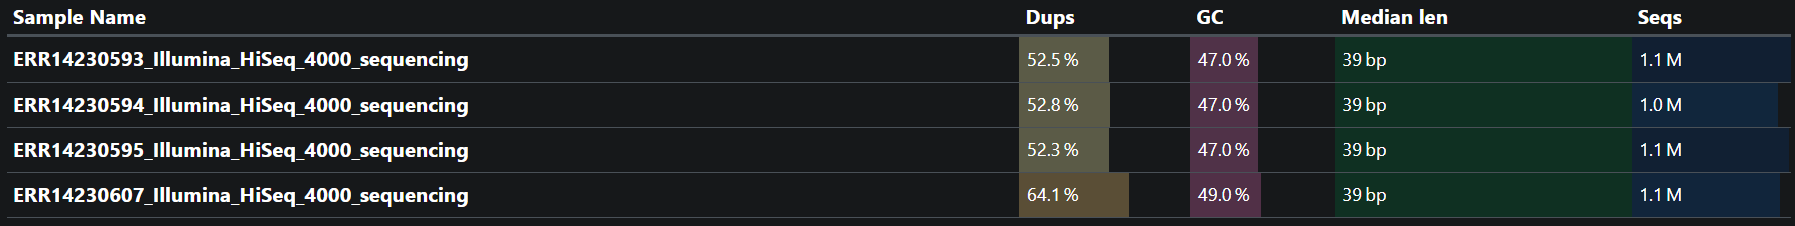

*    Образцы 593, 594 и 595 схожи по параметрам (медианная длина ридов, количество ридов, GC-состав). Образец 576  демонстрирует несколько повышенный уровень дупликации (64.1 %) и GC-содержание, возможно это связано с технологией приготовления бибилиотеки на этапе ПЦР

##Часть 2 — Тримминг


1)   Адаптерные последовательности не обнаружены ни в одном из четырёх образцов (загрязнение < 0.1%)

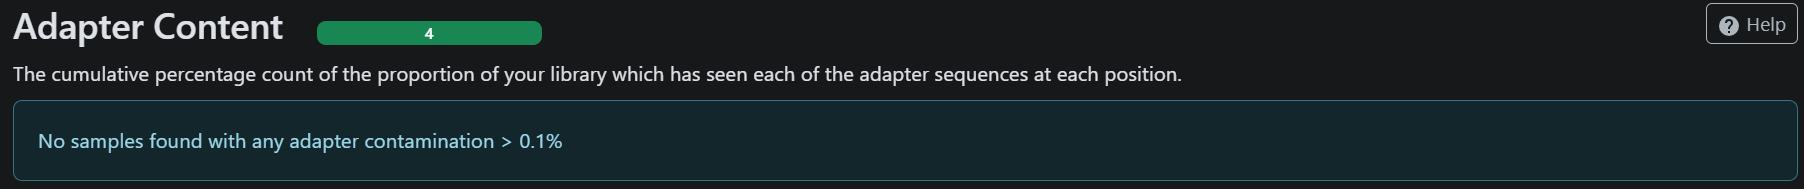

2)   Все четыре образца демонстрируют высокое качество прочтений — небольшое снижение наблюдается в первых 3 позициях (Q31-35) и в конце рида (до Q37), однако значение Q20 не достигается ни в одной позиции + все кривые практически совпадают, что говорит об однородном качестве данных

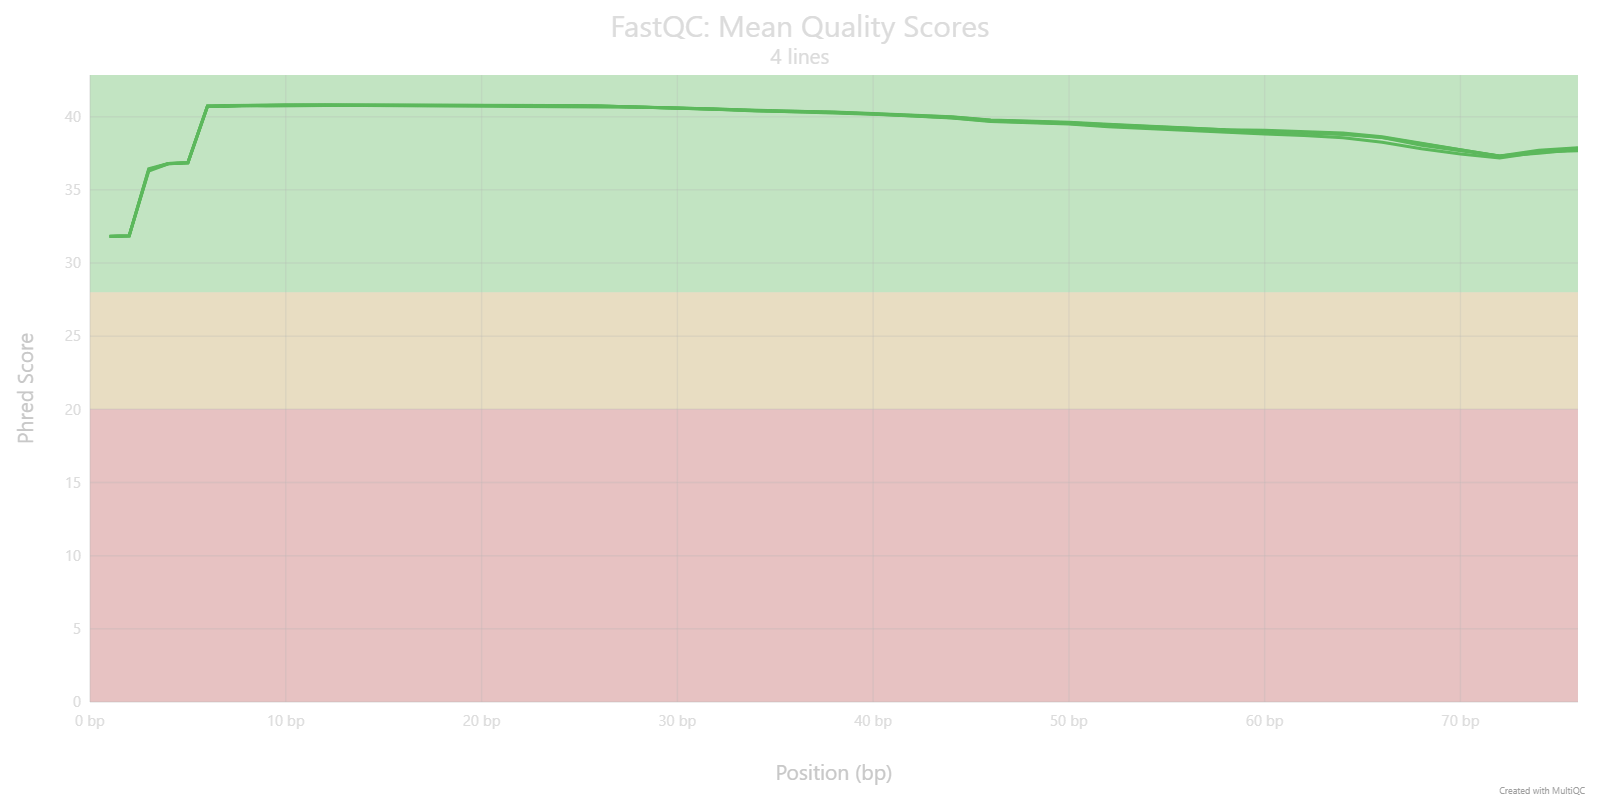

3)   На графике Per Base Seq Content видим, что в начале ридов (1 - 10 bp) есть неравномерность содержания нуклеотидов (скорее всего это связано с нулкеотидным составом праймеров при подготовке образца)

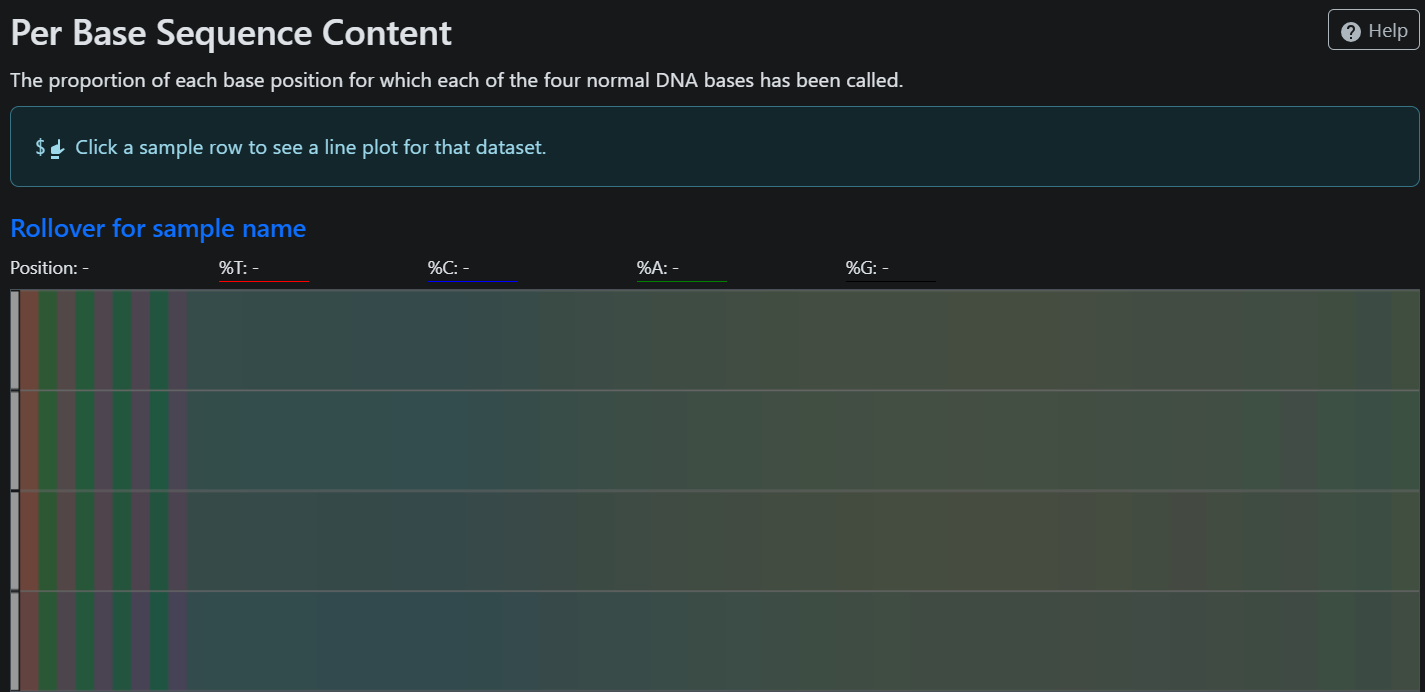

4)   Напишите SLURM скрипт `run_fastp.sh` для запуска тримминга  (fastp автоматически обрезает адаптеры)

In [ ]:
#!/bin/sh
#SBATCH --job-name=run_fastp     # Job name
#SBATCH --cpus-per-task=4         # Run on a single CPU
#SBATCH --mem=5gb                 # Job memory request
#SBATCH --time=00:10:00           # Time limit hrs:min:sec
#SBATCH --output=JobName.%j.log   # Standard output and error log
#SBATCH --partition=IXG6154-AI-common

source ~/soft/miniconda3/etc/profile.d/conda.sh
conda activate base

DATA=/home/STUDY/FBMF/studfbmf02_05/hw/hw_5/data
TRIMMED=/home/STUDY/FBMF/studfbmf02_05/hw/hw_5/res/trimmed

mkdir -p "$TRIMMED"

for FILE in "$DATA"/*.fastq.gz; do
    SAMPLE=$(basename "$FILE" .fastq.gz)
    fastp \
        --in1 "$FILE" \
        --out1 "$TRIMMED/${SAMPLE}_trimmed.fastq.gz" \
        --cut_right \
        --cut_window_size 5 \
        --cut_mean_quality 20 \
        --length_required 36 \
        --thread 4
done

5)   Выведем полученные файлы после тримминга

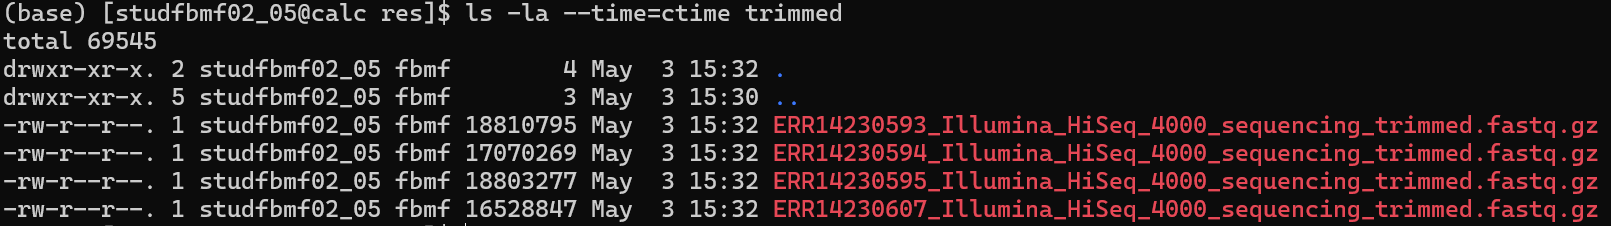

##Часть 3 — Контроль качества после тримминга


1)   На полученных файлах _trimmed.fastq.gz снова запустим анализ через `run_fastqc_trim.sh` скрипт:

In [ ]:
#!/bin/sh
#SBATCH --job-name=run_fastqc     # Job name
#SBATCH --cpus-per-task=4         # Run on a single CPU
#SBATCH --mem=5gb                 # Job memory request
#SBATCH --time=00:10:00           # Time limit hrs:min:sec
#SBATCH --output=JobName.%j.log   # Standard output and error log
#SBATCH --partition=IXG6154-AI-common

source ~/soft/miniconda3/etc/profile.d/conda.sh
conda activate base

TRIMMED=/home/STUDY/FBMF/studfbmf02_05/hw/hw_5/res/trimmed
RESULTS=/home/STUDY/FBMF/studfbmf02_05/hw/hw_5/res/res_new
mkdir -p "$RESULTS"
fastqc "$TRIMMED"/*_trimmed.fastq.gz \
    --outdir "$RESULTS" \
    --threads 4

multiqc "$RESULTS" \
    --outdir /home/STUDY/FBMF/studfbmf02_05/hw/hw_5/res/res_new \
    --filename multiqc_report_trimmed

2)   Также соберем отчет MultiQC

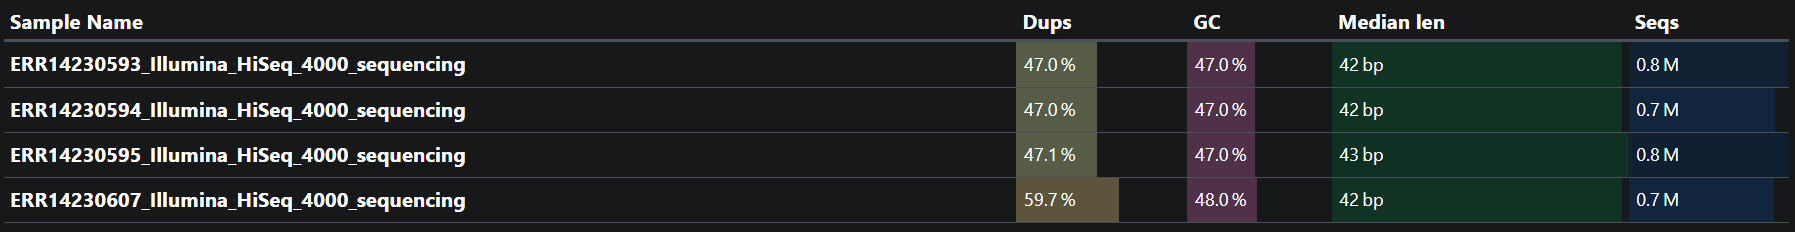

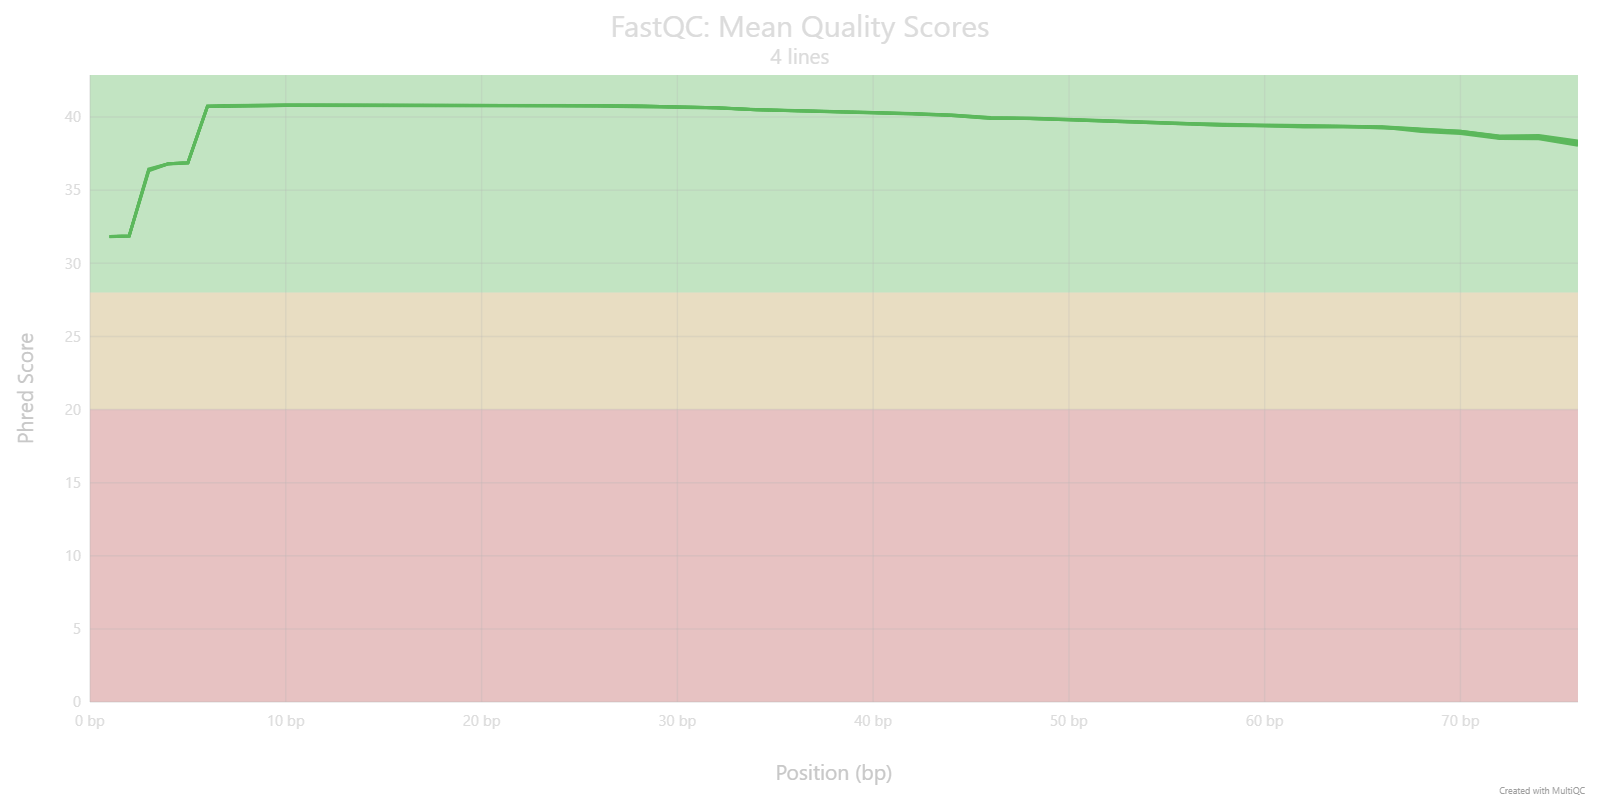

**Выводы:**

*   Все четыре образца стали более однородными. Медианная длина ридов увеличилась с 39 bp до 42-43 bp  + количество ридов немного уменьшилось (тк часть ридов не прошла фильтрацию по длине в 36 bp)

*   График качества по позициям после тримминга показывает маленькое улучшение, мы видим, что в конце ридов просадка до Q37 отсутствует

*   Изначально мы брали образцы с высоким качеством секвенирования и самое главное - с отсутствием адаптерных последовательностей, поэтому тримминг в нашей работе не дал кардинальных изменений

*   Также стоит отметить, что параметр для скользящего окна был довольно "мягким", изначально наше качество ридов было не меньше Q30